<a href="https://colab.research.google.com/github/sanjukadam/project/blob/master/CNN_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras import utils
import matplotlib.pyplot as plt

In [2]:
# load and procecess data
(x_train, y_train), (x_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print('shape of training data:',x_train.shape)
print('shape of testing data :',y_train.shape)
print('shape of training sample:',x_test.shape[0])
print('shape of testing sample:',y_test.shape[0])

shape of training data: (60000, 28, 28)
shape of testing data : (60000,)
shape of training sample: 10000
shape of testing sample: 10000


In [4]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32')/255
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype('float32')/255


In [5]:
# convert class vectors to binary class matrices
y_training = utils.to_categorical(y_train, 10)
y_testing = utils.to_categorical(y_test, 10)

In [6]:
# Example of label
arr = y_train[100]
print(f"Original label for sample 100: {arr}")
label_one_hot = np.argmax(y_training[100])
print(f"One-hot encoded label for sample 100: {label_one_hot}")


Original label for sample 100: 5
One-hot encoded label for sample 100: 5


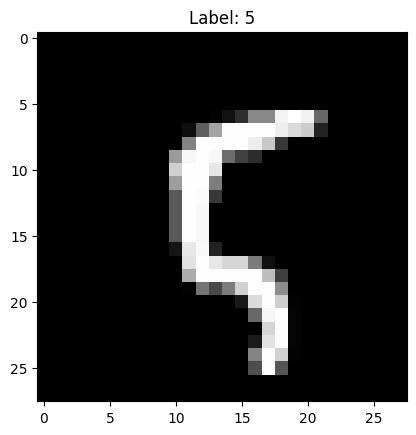

In [7]:
# Display an image

plt.imshow(x_train[100].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y_train[100]}")
plt.show()


In [8]:
# Build the model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# The following lines were redundant as Flatten and Dense layers were already added above
# Flat_layer=Flatten()
# model.add(Flat_layer)
# output_layer=Dense(10,activation='softmax')
# model.add(output_layer)


In [11]:
#compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [12]:
history = model.fit(x_train, y_training, batch_size=32, epochs=10, verbose=1, validation_data=(x_test, y_testing))

Epoch 1/10
 271/1875 ━━━━━━━━━━━━━━━━━━━━ 2:12 83ms/step - accuracy: 0.7100 - loss: 0.8892

KeyboardInterrupt: 

In [13]:
# Evaluate the model
# Corrected: Use y_testing (one-hot)
val_loss, val_acc = model.evaluate(x_test, y_testing, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Validation Loss: 0.1462
Validation Accuracy: 0.9595


In [14]:

# Make a prediction
# Corrected: Reshape single sample for prediction and use np.expand_dims
sample_to_predict = x_train[100]
# Add a batch dimension
sample_to_predict = np.expand_dims(sample_to_predict, axis=0)
arr = model.predict(sample_to_predict)
print(f"Prediction probabilities: {arr}")
predicted_class = np.argmax(arr)
print(f"Predicted class: {predicted_class}")
print(f"True label: {y_train[100]}") # Changed to y_train for original label or label_one_hot for encoded

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Prediction probabilities: [[0.00562665 0.00140705 0.00101168 0.01098705 0.00319395 0.7832162
  0.0148561  0.00232969 0.11864227 0.05872942]]
Predicted class: 5
True label: 5
